In [1]:
%load_ext autoreload
%autoreload 2

In [39]:
import numpy as np

import matplotlib.pyplot as plt
from mad.configs.ballistic_objects import titan_stage_1, titan_stage_2, B53_warhead
from mad.configs.planets import EARTH_SETTINGS
from mad.objs.planets import Planet, PlanetConfig
from mad.objs.missiles import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, PayloadConfig
from mad.objs.guidances import TabulatedBallistic, RCSGuidance, ProportionalNavigation
from mad.simulation import Simulation
from mad.logger import SourceLogger

logger = SourceLogger()

In [182]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 12000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.create_2D_point(name="Launchpad", altitude=10)
target = earth.create_2D_point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [204]:
stage1 = MissileStage(MissileStageConfig(**titan_stage_1))
stage2 = MissileStage(MissileStageConfig(**titan_stage_2))

missile_guidance = TabulatedBallistic(planet=earth, target=target, ballistic_table_path="B53_warhead_fine")

warhead_guidance = ProportionalNavigation(planet=earth, target=target, N=10.)
#  warhead_guidance = TabulatedBallistic(planet=earth, target=target, ballistic_table_path="B53_warhead_-90_90")
payload_cfg = PayloadConfig(**B53_warhead)
payload_cfg.guidance = warhead_guidance
payload_cfg.RCS_thrust = 0.0

missile_cfg = BallisticMissileConfig(stages=[stage1, stage2], guidance=missile_guidance, payload=payload_cfg)
titan = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Titan I")

titan

BallisticMissile Titan I, active.
Stages: Stage1, Stage2.
Available deltaV: 12039.61 m/s.
Burned Fraction: 0.00.

In [205]:
dt = 1.0
max_time = 20_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[titan],
)

results = sim.results


20:11:49 | INFO     | Simulation   | Starting simulation.
20:11:49 | INFO     | Missile      | Stage1 ran out of propellant at 110.00.
20:11:49 | INFO     | Missile      | Titan I - Stage1 separated at 110.00.
20:11:49 | INFO     | Simulation   | Stage1 added to Simulation.
20:11:49 | INFO     | Guidance     | Ballistic phase at t=334.0s, altitude=364.5km, velocity=7226.1m/s, range error: -160.3km.
20:11:49 | INFO     | Missile      | Titan I switched to ballistic phase at 334.00.
20:11:49 | INFO     | Missile      | Titan I released payload B53_Warhead at 334.00.
20:11:49 | INFO     | Missile      | Titan I - Stage2 separated at 334.00.
20:11:49 | INFO     | Missile      | Titan I inactivated at 334.00.
20:11:49 | INFO     | Simulation   | B53_Warhead added to Simulation.
20:11:49 | INFO     | Simulation   | Stage2 added to Simulation.
20:11:49 | INFO     | Projectile   | Stage1 landed on the ground!
20:11:49 | INFO     | Guidance     | PN armed at altitude 297.0 km, range 235.2 km.
2

/tmp/ipykernel_4360/2789105891.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend()


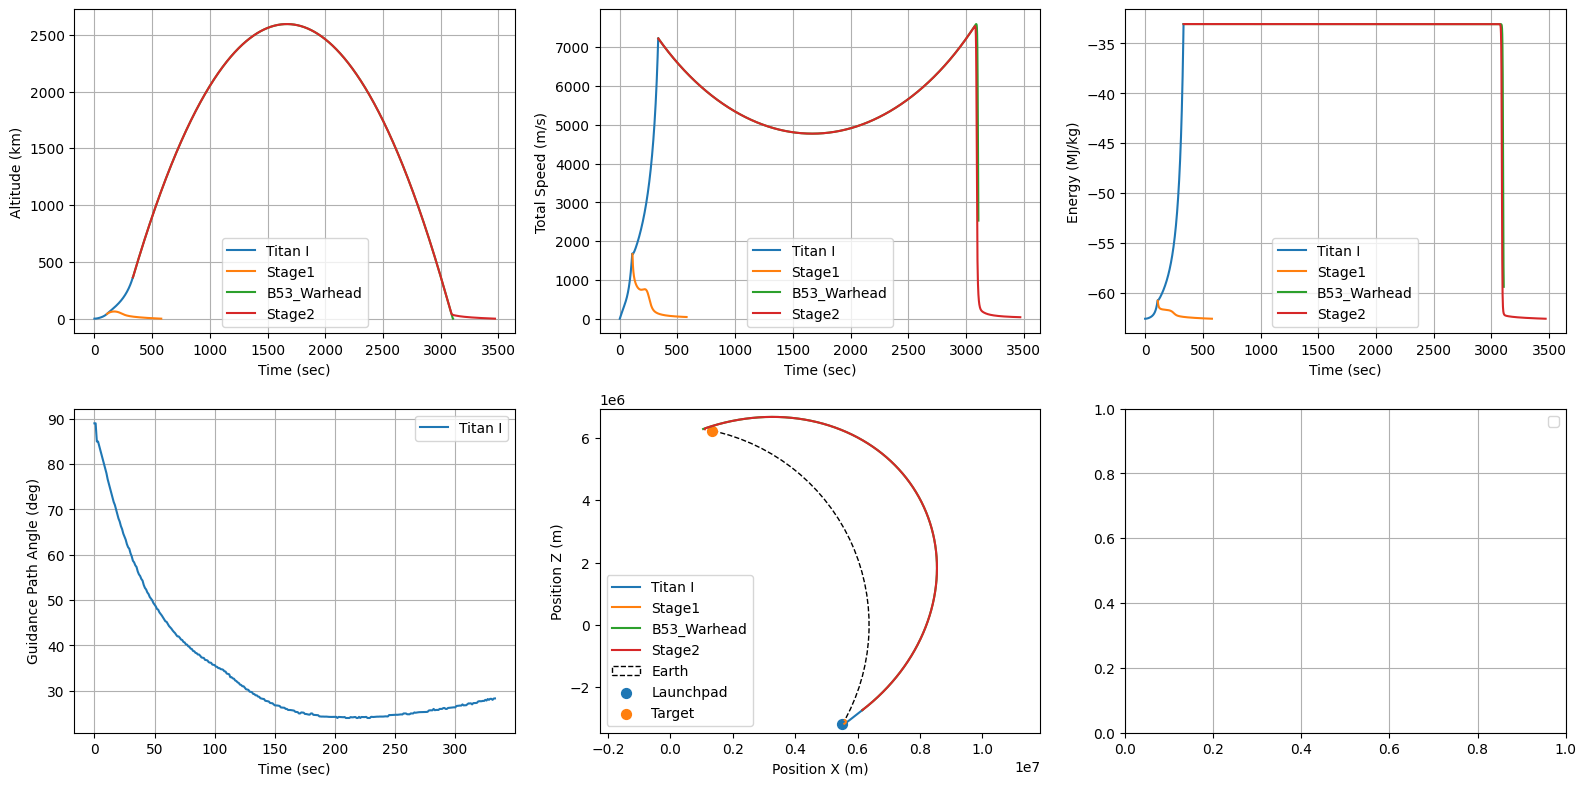

In [206]:
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(16, 8))
ax = ax.ravel()

for obj, result in results.items():

    ax[0].plot(result["time"], result["altitude"] / 1000, label=obj)
    ax[1].plot(result["time"], result["velocity"], label=obj)
    ax[2].plot(result["time"], result["energy"] / 1000_000, label=obj)
    if "gamma" in result and len(result["gamma"]) > 0:
        ax[3].plot(result["time"], np.degrees(result["gamma"]), label=obj)
    ax[4].plot(result["posx"], result["posz"], label=obj)


ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Energy (MJ/kg)")

ax[3].set_xlabel("Time (sec)")
ax[3].set_ylabel("Guidance Path Angle (deg)")

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[4], display_planet=True)
ax[4].set_xlabel("Position X (m)")
ax[4].set_ylabel("Position Z (m)")
ax[4].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()


fig.tight_layout(pad=1.2)

In [144]:
291/12000 * 100

2.4250000000000003